In [1]:
# import packages
import numpy as np
import time
from os.path import exists
import matplotlib.pyplot as plt

In [2]:
from MPDO import MPDO

In [3]:
# parameters
g = 1
L = 10
N = 7
Na = 3
t_hop = 1.0
W = 0.2
dt = 0.01
T = 0.25
# cutoff = 1e-16
seed = 42
# d = 3
chi = 32
Nt = int(T/dt)
t_grid = np.linspace(0, T, Nt)


In [ ]:
tr_TB = []
ni = np.zeros((L, Nt))

In [5]:
mps_evolve = MPDO(L,N,Na,t_hop,W,dt,T,chi,seed,g)
if exists("py_print.txt"):
    f = open("py_print.txt","w")
    f.write('New run\n')
    f.close
else:
    f = open("py_print.txt","x")
    f.write('New run\n')
    f.close()
for i in range(Nt):
    t1 = time.time()
    mps_evolve.sweepU()
    t2 = time.time()
    f = open("py_print.txt","a")
    f.write('Time step = '+str(i)+', time taken = '+str(t2-t1)+' for each step\n')
    #print('Time step = '+str(i)+', time taken = '+str(t2-t1)+' for each step')
    f.close()
    for j in range(L):
        ni[j][i] = mps_evolve.ni_persite[j]
        # print(ni[j,i])
    tr_TB.append(mps_evolve.tr_TEBD)

/var/folders/2w/lw0n043x0qv9lhtp8kpmwd7c0000gn/T/ipykernel_55301/3986131020.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  ni[j][i] = mps_evolve.ni_persite[j]


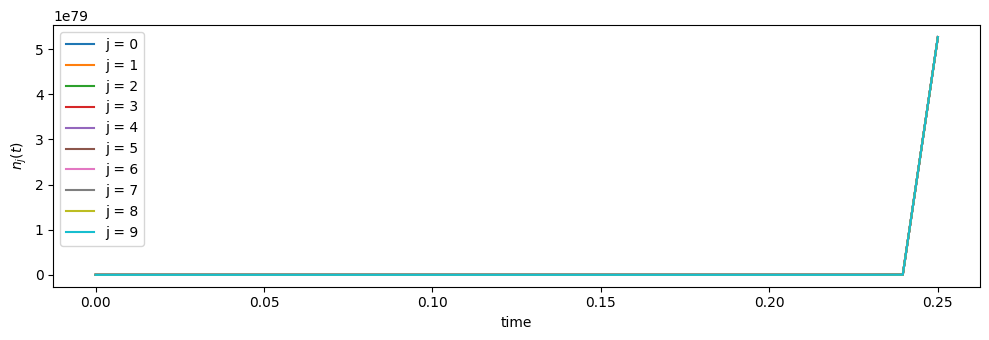

In [7]:
plt.figure(figsize=(10,3.5))
for j in range(L):
    plt.plot(t_grid, ni[j, :], label=f"j = {j}")
plt.xlabel('time')
plt.ylabel(r'$n_j(t)$')
plt.legend()
plt.tight_layout()
plt.show()